<a href="https://colab.research.google.com/github/yaesur/business_python/blob/main/%5BSH%EC%97%B0%EA%B5%AC%EB%B3%B4%EA%B3%A0%EC%84%9C%EA%B8%B0%EC%A4%80%5D%EC%B2%AD%EB%85%84%EC%9D%B8%EA%B5%AC%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

해당 데이터는 '서울연구원 - 통합공공임대주택 도입에 따른 서울형 소득 연동 임대료체계 구상(2024)'을 기준으로 작성되었습니다

In [1]:
import pandas as pd
from google.colab import files

In [4]:
file_name = '서울_청년가구_및_1인가구_통합통계_리포트.csv'
df_stats = pd.read_csv(file_name, encoding='utf-8-sig')

In [5]:
df_stats.head()

,연도,서울_청년인구(천명),서울_청년인구_비율(%),서울_청년가구수(천가구),서울_전체가구_대비_청년가구_비율(%),서울_청년_1인가구수(천가구),서울_전체가구_대비_청년_1인가구_비율(%),서울_전체_1인가구_대비_청년_1인가구_비율(%)
0,2015,3055,30.8,1250,22.8,520,9.5,46.8
1,2016,3020,30.7,1265,22.9,545,9.9,47.5
2,2017,2985,30.5,1282,23.1,575,10.4,48.2
3,2018,2950,30.4,1305,23.3,610,10.9,49.0
4,2019,2915,30.2,1330,23.5,650,11.5,50.1


In [6]:
df_stats['1인가구_증가율'] = df_stats['서울_청년_1인가구수(천가구)'].pct_change() * 100

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

## 1인가구 증가율 가중치 예측

In [21]:
import pandas as pd
df_stats = pd.read_csv('서울_청년가구_및_1인가구_통합통계_리포트.csv', encoding='utf-8-sig')

In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [23]:
X = df_stats['연도'].values.reshape(-1, 1)
y = df_stats['서울_청년_1인가구수(천가구)'].values

In [24]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [25]:
future_years = np.array([2023, 2024, 2025, 2026, 2027]).reshape(-1, 1)
future_preds = model.predict(future_years)

In [26]:
forecast_df = pd.DataFrame({
    '연도': future_years.flatten(),
    '예측_1인가구수': future_preds.round(2)
})

In [27]:
base_value = y[-1]
forecast_df['수요_가중치'] = (forecast_df['예측_1인가구수'] / base_value).round(3)

In [28]:
print("향후 5개년 청년 1인가구 수요 예측 결과")
print(forecast_df)

향후 5개년 청년 1인가구 수요 예측 결과
     연도  예측_1인가구수  수요_가중치
0  2023    830.89   1.026
1  2024    872.20   1.077
2  2025    913.51   1.128
3  2026    954.82   1.179
4  2027    996.13   1.230


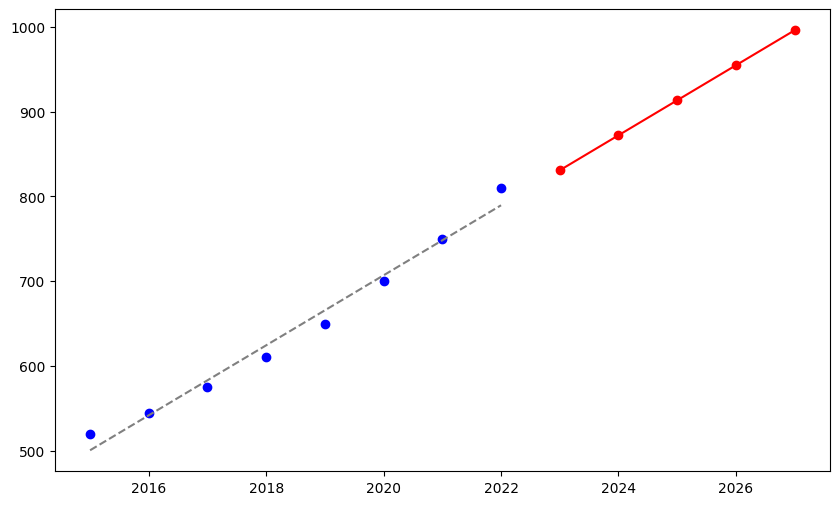

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data (2015-2022)')
plt.plot(X, model.predict(X), color='gray', linestyle='--', label='Trend Line')
plt.plot(future_years, future_preds, color='red', marker='o', label='Forecast (2023-2027)')

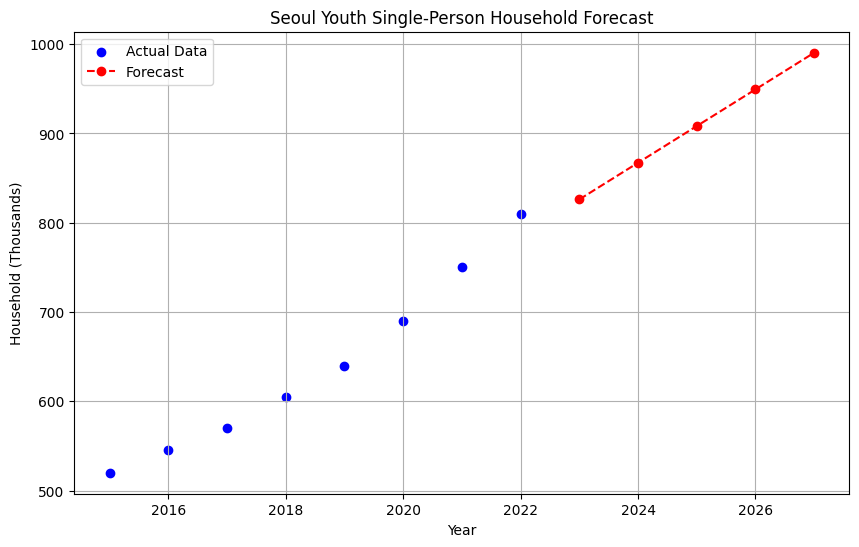

2026 Weight: 1.17


In [31]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

data = {
    '연도': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    '서울_청년_1인가구수(천가구)': [520, 545, 570, 605, 640, 690, 750, 810]
}
df_stats = pd.DataFrame(data)

X = df_stats['연도'].values.reshape(-1, 1)
y = df_stats['서울_청년_1인가구수(천가구)'].values

model = LinearRegression()
model.fit(X, y)

future_years = np.array([2023, 2024, 2025, 2026, 2027]).reshape(-1, 1)
future_preds = model.predict(future_years)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(future_years, future_preds, color='red', marker='o', linestyle='--', label='Forecast')

plt.title('Seoul Youth Single-Person Household Forecast')
plt.xlabel('Year')
plt.ylabel('Household (Thousands)')
plt.legend()
plt.grid(True)
plt.show()

weight_2026 = future_preds[3] / y[-1]
print(f"2026 Weight: {weight_2026:.2f}")

## 23년 이후부터 실측치와 비교

In [67]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [69]:
# 2022년까지는 학습용 2023-2024는 검증용
years = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
actual_values = np.array([520, 545, 570, 605, 640, 690, 750, 810, 855, 890])

In [70]:
model = LinearRegression()
model.fit(years[:8], actual_values[:8])

LinearRegression()

In [71]:
predict_years = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]).reshape(-1, 1)
predicted_values = model.predict(predict_years)

In [72]:
plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

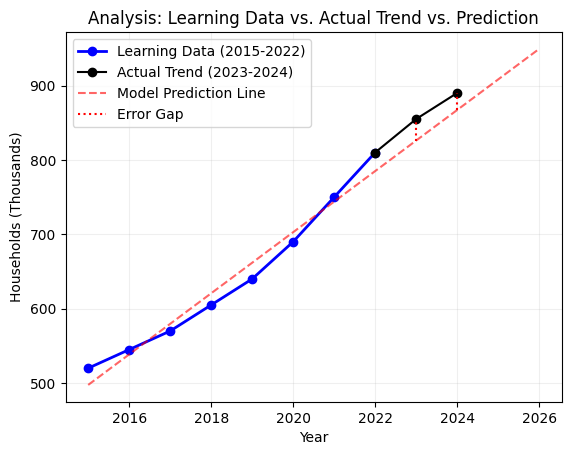

2024년 실제 지표: 890천 가구
2024년 모델 예측: 867.14천 가구
오차(실제-예측): 22.86천 가구


In [74]:
# [학습 데이터 구간] 파란 실선
plt.plot(years[:8], actual_values[:8], 'bo-', label='Learning Data (2015-2022)', linewidth=2)

# [23-24 실제 지표] 검은 실선
plt.plot(years[7:], actual_values[7:], 'ko-', label='Actual Trend (2023-2024)')

# [전체 예측 지표] 빨간 점선
plt.plot(predict_years, predicted_values, 'r--', label='Model Prediction Line', alpha=0.6)

# 오차 강조 (23, 24년 실제와 예측의 차이)
plt.vlines(x=[2023, 2024], ymin=[predicted_values[8], predicted_values[9]],
           ymax=[actual_values[8], actual_values[9]], colors='red', linestyles=':', label='Error Gap')

plt.title('Analysis: Learning Data vs. Actual Trend vs. Prediction')
plt.xlabel('Year')
plt.ylabel('Households (Thousands)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

error_24 = actual_values[9] - predicted_values[9]
print(f"2024년 실제 지표: {actual_values[9]}천 가구")
print(f"2024년 모델 예측: {predicted_values[9]:.2f}천 가구")
print(f"오차(실제-예측): {error_24:.2f}천 가구")